In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [9]:
folder = "images/building"
images = []

for file in sorted(os.listdir(folder)):
    img = cv2.imread(os.path.join(folder, file))
    
    if img is not None:
        images.append(img)
        print("Loaded:", file)


Loaded: p1.png
Loaded: p2.png


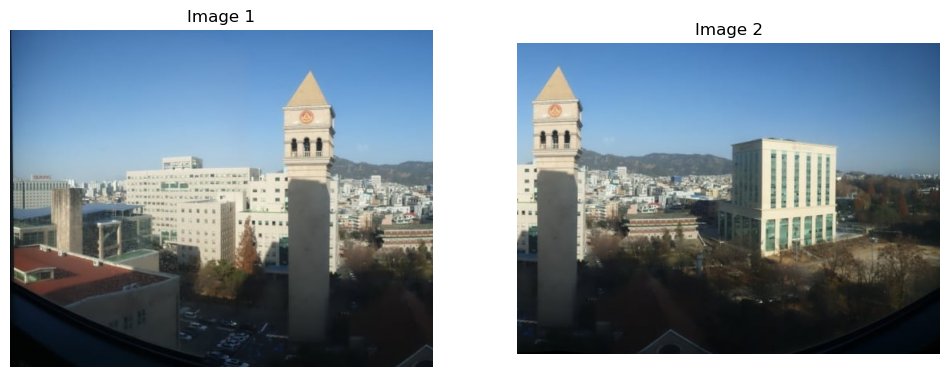

In [10]:
plt.figure(figsize=(12,6))

for i,img in enumerate(images):
    
    plt.subplot(1,len(images),i+1)
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.show()

In [11]:
def detect_features(img1, img2):

    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    return kp1, des1, kp2, des2

In [12]:
def match_features(des1, des2):

    matcher = cv2.BFMatcher()
    matches = matcher.knnMatch(des1, des2, k=2)

    good = []

    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return good

In [13]:
def find_homography(kp1, kp2, matches):

    if len(matches) < 10:
        print("Not enough matches")
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

    H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5)

    return H

In [14]:
def stitch_images(img1, img2, H):

    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    result = cv2.warpPerspective(img2, H, (w1 + w2, h1))

    result[0:h1, 0:w1] = img1

    return result

In [15]:
panorama = images[0]

for i in range(1, len(images)):

    print("Stitching image", i+1)

    kp1, des1, kp2, des2 = detect_features(panorama, images[i])

    matches = match_features(des1, des2)

    H = find_homography(kp1, kp2, matches)

    if H is not None:
        panorama = stitch_images(panorama, images[i], H)

Stitching image 2


Stitching image 2


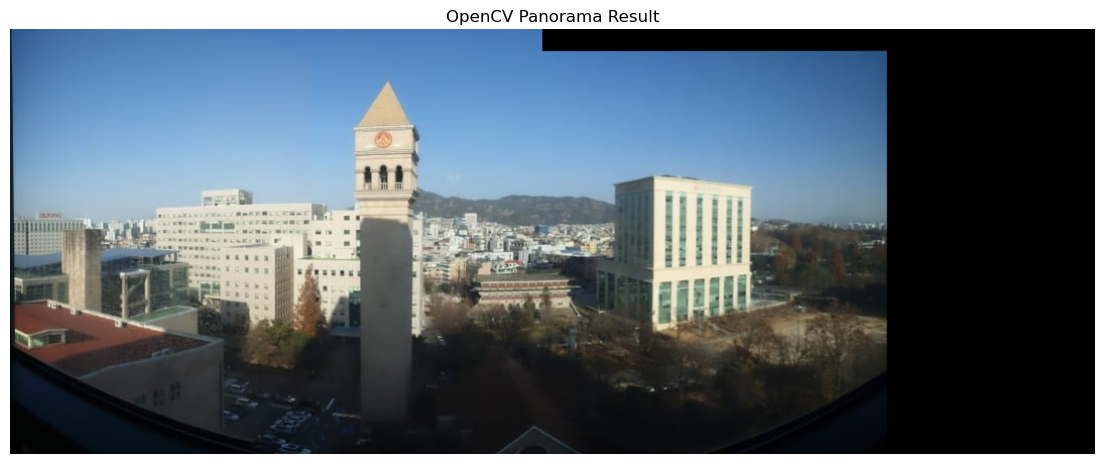

Panorama saved as deep_stitched_panorama.jpg


In [16]:
panorama = images[0]
for i in range(1, len(images)):
    print("Stitching image", i+1)
    kp1, des1, kp2, des2 = detect_features(panorama, images[i])
    matches = match_features(des1, des2)
    H = find_homography(kp1, kp2, matches)
    if H is not None:
        panorama = stitch_images(panorama, images[i], H)

        plt.figure(figsize=(14,7))
        plt.imshow(cv2.cvtColor(panorama,cv2.COLOR_BGR2RGB))
        plt.title("OpenCV Panorama Result")
        plt.axis("off")
        plt.show()

cv2.imwrite("deep_stitched_panorama.jpg", panorama)
print("Panorama saved as deep_stitched_panorama.jpg")